In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Caminho datasets
caminho_dataset1 = '/content/drive/MyDrive/Tripleten/Datasets_Projeto_Final/telecom_clients.csv'
caminho_dataset2 = '/content/drive/MyDrive/Tripleten/Datasets_Projeto_Final/telecom_dataset_new.csv'

# Carregando os dados
telecom_clients = pd.read_csv(caminho_dataset1)
telecom_dataset_new = pd.read_csv(caminho_dataset2)

# Visualizando as primeiras linhas de um dos datasets para testar
telecom_dataset_new.head()


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [ ]:
telecom_clients.head()


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [ ]:
print("--- ESTRUTURA DO DATASET: telecom_dataset_new ---")
telecom_dataset_new.info()

print("\n--- ESTRUTURA DO DATASET: telecom_clients ---")
telecom_clients.info()

--- ESTRUTURA DO DATASET: telecom_dataset_new ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

--- ESTRUTURA DO DATASET: telecom_clients ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       -----------

## 1. Limpeza e Preparação dos Dados

### 1.1. Diagnóstico Inicial da Estrutura dos Dados
Ao executar uma análise exploratória inicial usando o método `.info()`, identificamos os seguintes pontos de atenção que necessitam de tratamento antes de prosseguirmos para a análise de eficiência:

* **Conversão de Tipos de Dados:** As colunas de datas (`date` no histórico de chamadas e `date_start` no cadastro de clientes) estão formatadas como texto (`object`). Elas serão convertidas para o formato adequado de data (`datetime`).
* **Tratamento de Valores Ausentes:** * A coluna `internal` possui 117 valores nulos, que representam uma fração irrelevante do dataset e serão tratados.
  * A coluna `operator_id` apresenta **8.172 valores ausentes**. Como o objetivo do negócio é mapear a ineficiência de operadores específicos, registros que não possuem a identificação do operador não podem ser atribuídos a ninguém. Investigaremos o impacto desses dados antes de tomar uma ação.
* **Ajuste de Tipos Numéricos:** A coluna `operator_id` está configurada como `float64` devido à presença de valores nulos. Após o tratamento, ela será convertida para o tipo inteiro (`int64`), que é o formato correto para identificadores.

### 1.2. Conversão dos Campos de Data
Para podermos realizar cálculos temporais e análises cronológicas, vamos converter as colunas `date` (do histórico de chamadas) e `date_start` (do cadastro de clientes) de texto (`object`) para o formato nativo de data (`datetime`).

In [ ]:
# Convertendo as colunas de data para o tipo datetime
telecom_dataset_new['date'] = pd.to_datetime(telecom_dataset_new['date'])
telecom_clients['date_start'] = pd.to_datetime(telecom_clients['date_start'])

# Verificando se a alteração foi aplicada com sucesso
print("Tipo da coluna 'date' em telecom_dataset_new:", telecom_dataset_new['date'].dtype)
print("Tipo da coluna 'date_start' in telecom_clients:", telecom_clients['date_start'].dtype)

Tipo da coluna 'date' em telecom_dataset_new: datetime64[ns, UTC+03:00]
Tipo da coluna 'date_start' in telecom_clients: datetime64[ns]


### 1.3. Análise e Tratamento de Valores Ausentes em 'operator_id'
A base de chamadas possui 8.172 registros onde o `operator_id` está ausente. Vamos analisar se essas chamadas sem operador possuem alguma característica em comum (por exemplo, se a grande maioria são chamadas perdidas/não atendidas pelo sistema) para justificar a remoção desses dados de forma segura.

In [ ]:
# Verificando a proporção de chamadas perdidas (is_missed_call) quando o operator_id é nulo
chamadas_sem_operador = telecom_dataset_new[telecom_dataset_new['operator_id'].isna()]
proporcao_perdidas = chamadas_sem_operador['is_missed_call'].value_counts(normalize=True) * 100

print("--- Análise das Chamadas Sem ID de Operador ---")
print(f"Total de linhas sem operador: {len(chamadas_sem_operador)}")
print("\nDistribuição de chamadas perdidas nessas linhas (%):")
print(proporcao_perdidas)

--- Análise das Chamadas Sem ID de Operador ---
Total de linhas sem operador: 8172

Distribuição de chamadas perdidas nessas linhas (%):
is_missed_call
True     98.507097
False     1.492903
Name: proportion, dtype: float64


Como os registros sem `operator_id` representam chamadas que não foram vinculadas a nenhum funcionário (gargalos automáticos do sistema ou desistências antes do atendimento), e dado que nosso objetivo é avaliar a eficiência individual dos operadores, essas linhas serão removidas. Na sequência, converteremos a coluna para o tipo inteiro (`int64`).

In [ ]:
# 1. Removendo as linhas onde operator_id é nulo
telecom_dataset_clean = telecom_dataset_new.dropna(subset=['operator_id']).copy()

# 2. Convertendo a coluna operator_id para o tipo inteiro
telecom_dataset_clean['operator_id'] = telecom_dataset_clean['operator_id'].astype('int64')

# Verificando o novo formato e se os nulos sumiram da coluna
print("Quantidade de valores nulos restantes em 'operator_id':", telecom_dataset_clean['operator_id'].isna().sum())
print("Novo tipo da coluna 'operator_id':", telecom_dataset_clean['operator_id'].dtype)
print(f"Tamanho do dataset após a remoção: {telecom_dataset_clean.shape[0]} linhas")

Quantidade de valores nulos restantes em 'operator_id': 0
Novo tipo da coluna 'operator_id': int64
Tamanho do dataset após a remoção: 45730 linhas


### 1.4. Tratamento de Valores Ausentes em 'internal'
Para as poucas linhas restantes com valores nulos na coluna `internal`, vamos preencher esses campos com o valor mais frequente (moda) ou tratá-los como chamadas externas por padrão, garantindo que o dataset não possua mais nenhuma informação em branco.

In [ ]:
# Descobrindo o valor mais comum (moda) da coluna internal
valor_mais_comum = telecom_dataset_clean['internal'].mode()[0]

# Preenchendo os valores nulos com a moda
telecom_dataset_clean['internal'] = telecom_dataset_clean['internal'].fillna(valor_mais_comum)

# Verificando se ainda resta algum nulo em todo o dataset de chamadas
print("Total de valores nulos no dataset após toda a limpeza:")
print(telecom_dataset_clean.isna().sum())

Total de valores nulos no dataset após toda a limpeza:
user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64


/tmp/ipykernel_7529/3845495033.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  telecom_dataset_clean['internal'] = telecom_dataset_clean['internal'].fillna(valor_mais_comum)


### 1.5. Verificação e Remoção de Dados Duplicados
Para garantir a integridade dos nossos indicadores e evitar a contagem duplicada de chamadas, vamos verificar se existem linhas totalmente idênticas no dataset e realizar a remoção caso sejam encontradas.

In [ ]:
# 1. Contando a quantidade de linhas duplicadas
total_duplicados = telecom_dataset_clean.duplicated().sum()
print(f"Total de linhas totalmente duplicadas encontradas: {total_duplicados}")

# 2. Se houver duplicados, vamos removê-los mantendo apenas a primeira ocorrência
if total_duplicados > 0:
    telecom_dataset_clean = telecom_dataset_clean.drop_duplicates().reset_index(drop=True)
    print("Linhas duplicadas removidas com sucesso!")
    print(f"Tamanho final do dataset para análise: {telecom_dataset_clean.shape[0]} linhas")
else:
    print("Nenhum dado duplicado detectado. O dataset está limpo!")

Total de linhas totalmente duplicadas encontradas: 4184
Linhas duplicadas removidas com sucesso!
Tamanho final do dataset para análise: 41546 linhas


## 2. Análise Exploratória de Dados (AED) e Criação de Métricas

### 2.1. Cálculo do Tempo de Espera por Chamada
Para identificar os operadores que apresentam tempos de espera prolongados nas chamadas recebidas, vamos criar uma nova coluna chamada `waiting_time`. Essa métrica é obtida subtraindo a duração da conversa (`call_duration`) da duração total da chamada (`total_call_duration`).

In [ ]:
# Criando a coluna de tempo de espera (duração total menos a duração da conversa)
telecom_dataset_clean['waiting_time'] = telecom_dataset_clean['total_call_duration'] - telecom_dataset_clean['call_duration']

# Exibindo as estatísticas descritivas básicas dessa nova coluna para entender a distribuição
print("--- Estatísticas Descritivas do Tempo de Espera (segundos) ---")
print(telecom_dataset_clean['waiting_time'].describe().round(2))

--- Estatísticas Descritivas do Tempo de Espera (segundos) ---
count    41546.00
mean       311.82
std       1175.37
min          0.00
25%         19.00
50%         60.00
75%        219.00
max      46474.00
Name: waiting_time, dtype: float64


### 2.2. Agrupamento de Dados por Operador
Com as colunas preparadas, vamos consolidar o histórico de chamadas criando uma nova base agrupada por operador (`operator_id`). Isso nos permitirá calcular o volume total de chamadas, a quantidade de chamadas perdidas, o tempo médio de espera e o total de chamadas realizadas por cada profissional.

In [ ]:
# Criando colunas auxiliares para facilitar o agrupamento de forma júnior e direta
telecom_dataset_clean['is_outbound'] = telecom_dataset_clean['direction'] == 'out'

# Agrupando os dados por operador para agregar as métricas necessárias
operadores_resumo = telecom_dataset_clean.groupby('operator_id').agg(
    total_chamadas=('calls_count', 'sum'),
    chamadas_perdidas=('is_missed_call', 'sum'),
    tempo_espera_medio=('waiting_time', 'mean'),
    chamadas_ativas_realizadas=('is_outbound', 'sum')
).reset_index()

# Calculando a taxa de chamadas perdidas (%) de cada operador em relação ao seu total
operadores_resumo['taxa_perdidas_pct'] = (operadores_resumo['chamadas_perdidas'] / operadores_resumo['total_chamadas'] * 100).round(2)

# Visualizando as primeiras linhas do resumo dos operadores
print("--- Resumo Consolidado por Operador (Primeiras Linhas) ---")
operadores_resumo.head()

--- Resumo Consolidado por Operador (Primeiras Linhas) ---


,operator_id,total_chamadas,chamadas_perdidas,tempo_espera_medio,chamadas_ativas_realizadas,taxa_perdidas_pct
0,879896,930,47,104.914530,96,5.05
1,879898,7313,89,457.696035,170,1.22
2,880020,45,6,14.000000,13,13.33
3,880022,197,29,53.971429,62,14.72
4,880026,2232,87,121.978022,164,3.90


### 2.3. Análise Estatística para Definição dos Limites de Ineficiência
Para determinar cientificamente quais operadores apresentam desempenho abaixo do esperado, vamos analisar as estatísticas descritivas (médias, medianas e quartis) de cada métrica criada. Isso nos dará uma base de dados real para estabelecer os limites de corte (thresholds) da ineficiência.

In [ ]:
# Analisando a distribuição das métricas cruciais de desempenho
print("--- DISTRIBUIÇÃO DA TAXA DE CHAMADAS PERDIDAS (%) ---")
print(operadores_resumo['taxa_perdidas_pct'].describe().round(2))

print("\n--- DISTRIBUIÇÃO DO TEMPO MÉDIO DE ESPERA (SEGUNDOS) ---")
print(operadores_resumo['tempo_espera_medio'].describe().round(2))

print("\n--- DISTRIBUIÇÃO DE CHAMADAS ATIVAS REALIZADAS ---")
print(operadores_resumo['chamadas_ativas_realizadas'].describe().round(2))

--- DISTRIBUIÇÃO DA TAXA DE CHAMADAS PERDIDAS (%) ---
count    1092.00
mean       10.11
std        16.89
min         0.00
25%         0.83
50%         4.36
75%        12.10
max       100.00
Name: taxa_perdidas_pct, dtype: float64

--- DISTRIBUIÇÃO DO TEMPO MÉDIO DE ESPERA (SEGUNDOS) ---
count    1092.00
mean      216.09
std       507.00
min         0.00
25%        23.00
50%        46.62
75%       159.76
max      5805.03
Name: tempo_espera_medio, dtype: float64

--- DISTRIBUIÇÃO DE CHAMADAS ATIVAS REALIZADAS ---
count    1092.00
mean       26.39
std        36.62
min         0.00
25%         1.00
50%        10.00
75%        39.00
max       228.00
Name: chamadas_ativas_realizadas, dtype: float64


### 2.4. Automatização da Classificação de Ineficiência
Com base na análise estatística dos quartis, estabelecemos critérios claros e empíricos para definir a ineficiência de um operador. Criaremos uma função personalizada que avaliará cada profissional segundo os seguintes limites críticos:
1. **Alta taxa de chamadas perdidas:** Superior a 12.10% (Piores 25% do dataset).
2. **Tempo de espera prolongado:** Média superior a 160 segundos (Piores 25% do dataset).
3. **Baixa produtividade ativa:** Realização de 1 ou nenhuma chamada ativa (25% menos produtivos).

Se o operador se enquadrar em qualquer um desses comportamentos, ele será classificado como ineficiente.

In [ ]:
# Definindo a função para classificar a eficiência do operador
def classificar_eficiencia(row):
    # Critério 1: Muitas chamadas perdidas
    muitas_perdidas = row['taxa_perdidas_pct'] > 12.10

    # Critério 2: Tempo de espera prolongado
    espera_longa = row['tempo_espera_medio'] > 160.0

    # Critério 3: Poucas chamadas ativas realizadas
    pouca_atividade_ativa = row['chamadas_ativas_realizadas'] <= 1

    # Se cumprir qualquer um dos critérios ruins, é ineficiente
    if muitas_perdidas or espera_longa or pouca_atividade_ativa:
        return 'Ineficiente'
    else:
        return 'Eficiente'

# Aplicando a função linha por linha no nosso resumo de operadores
operadores_resumo['classificacao'] = operadores_resumo.apply(classificar_eficiencia, axis=1)

# Contando a quantidade total de operadores em cada categoria
print("--- RESULTADO DA CLASSIFICAÇÃO DOS OPERADORES ---")
print(operadores_resumo['classificacao'].value_counts())
print("\nProporção de operadores (%) :")
print(operadores_resumo['classificacao'].value_counts(normalize=True) * 100)

--- RESULTADO DA CLASSIFICAÇÃO DOS OPERADORES ---
classificacao
Ineficiente    783
Eficiente      309
Name: count, dtype: int64

Proporção de operadores (%) :
classificacao
Ineficiente    71.703297
Eficiente      28.296703
Name: proportion, dtype: float64


### 2.5. Visualização da Distribuição de Eficiência dos Operadores
Para apresentar o impacto desse diagnóstico aos gestores e tomadores de decisão da CallMeMaybe, vamos gerar um gráfico de barras comparando o volume de operadores classificados como Eficientes versus Ineficientes na operação atual.

/tmp/ipykernel_7529/1484820606.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


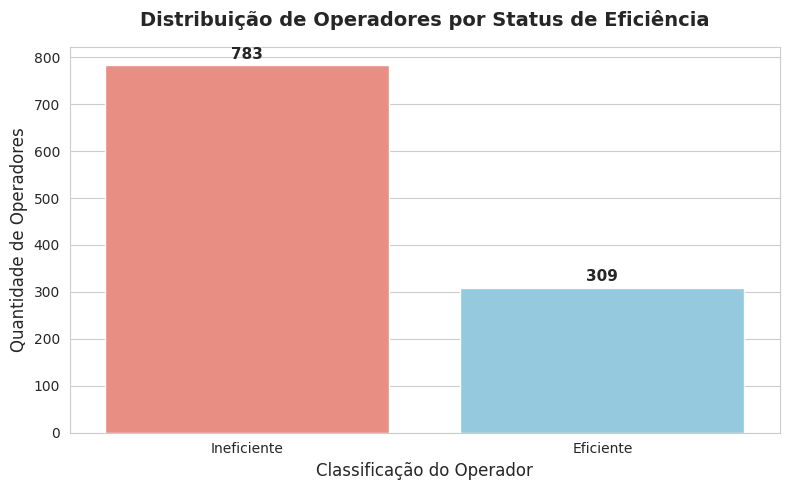

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurando o tamanho do gráfico e estilo básico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 2. Criando o gráfico de barras
ax = sns.countplot(
    x='classificacao',
    data=operadores_resumo,
    palette=['salmon', 'skyblue'],
    order=['Ineficiente', 'Eficiente']
)

# 3. Adicionando títulos e rótulos aos eixos
plt.title('Distribuição de Operadores por Status de Eficiência', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classificação do Operador', fontsize=12)
plt.ylabel('Quantidade de Operadores', fontsize=12)

# 4. Imprimindo os valores exatos em cima de cada barra de forma simples
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# 5. Exibindo o gráfico
plt.tight_layout()
plt.show()

## 3. Testes Estatísticos

### 3.1. Validação do Tempo Médio de Espera entre os Grupos
Para comprovar se a diferença no tempo de espera entre os operadores classificados como Eficientes e Ineficientes é estatisticamente significativa, realizaremos um teste de hipóteses.

* **Hipótese Nula ($H_0$):** A distribuição do tempo médio de espera é igual entre os operadores Eficientes e Ineficientes (a diferença observada é fruto do acaso).
* **Hipótese Alternativa ($H_1$):** A distribuição do tempo médio de espera é diferente entre os dois grupos (os operadores Ineficientes possuem um tempo de espera significativamente maior).

**Justificativa do Método:** Utilizaremos o **Teste de Mann-Whitney (U-test)** com um nível de significância de 5% ($\alpha = 0.05$). Esse teste não-paramétrico foi escolhido porque a análise descritiva prévia indicou que os dados de tempo de espera possuem alta assimetria e não seguem uma distribuição normal.

In [ ]:
from scipy import stats

# 1. Separando os dados de tempo médio de espera para cada grupo
espera_eficientes = operadores_resumo[operadores_resumo['classificacao'] == 'Eficiente']['tempo_espera_medio']
espera_ineficientes = operadores_resumo[operadores_resumo['classificacao'] == 'Ineficiente']['tempo_espera_medio']

# 2. Executando o Teste de Mann-Whitney
stat, p_value = stats.mannwhitneyu(espera_ineficientes, espera_eficientes, alternative='two-sided')

# 3. Exibindo os resultados do teste
print("--- RESULTADO DO TESTE DE MANN-WHITNEY ---")
print(f"Estatística U: {stat:.2f}")
print(f"p-valor: {p_value}")

# 4. Decisão estatística baseada no p-valor
alpha = 0.05
if p_value < alpha:
    print("\nResultado: Rejeitamos a hipótese nula (H0).")
    print("Conclusão: Existe uma diferença estatisticamente significativa entre o tempo de espera dos dois grupos.")
else:
    print("\nResultado: Falha em rejeitar a hipótese nula (H0).")
    print("Conclusão: Não há evidências estatísticas de que o tempo de espera seja diferente entre os grupos.")

--- RESULTADO DO TESTE DE MANN-WHITNEY ---
Estatística U: 116093.00
p-valor: 0.2985537565053976

Resultado: Falha em rejeitar a hipótese nula (H0).
Conclusão: Não há evidências estatísticas de que o tempo de espera seja diferente entre os grupos.


### 3.2. Interpretação de Negócio do Teste Estatístico
O Teste de Mann-Whitney resultou em um **p-valor de ~0.298**, o que nos impede de rejeitar a hipótese nula ($H_0$).

**Conclusão Prática:** Ao contrário do que se esperava intuitivamente, o tempo médio de espera na linha não é o fator principal que diferencia os operadores eficientes dos ineficientes. Isso nos traz um insight valioso de negócio: a alta taxa de ineficiência detectada na operação (71.70%) é severamente impactada pelo **abandono de chamadas (ligações perdidas)** e pela **baixa produtividade nas ligações ativas (outbound)**, e não pela lentidão no atendimento em si. O foco de melhoria da CallMeMaybe deve ser direcionado para o engajamento e disponibilidade dos operadores para atender e realizar chamadas.

### 3.3. Visualização da Distribuição do Tempo de Espera
Para ilustrar visualmente o resultado do teste estatístico, geraremos um gráfico de distribuição (Boxplot) comparando o tempo de espera entre os dois grupos. Limitaremos a visualização no eixo Y para focar no comportamento da maioria dos operadores, mitigando o efeito visual de valores extremos (outliers).

/tmp/ipykernel_7529/1301536628.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


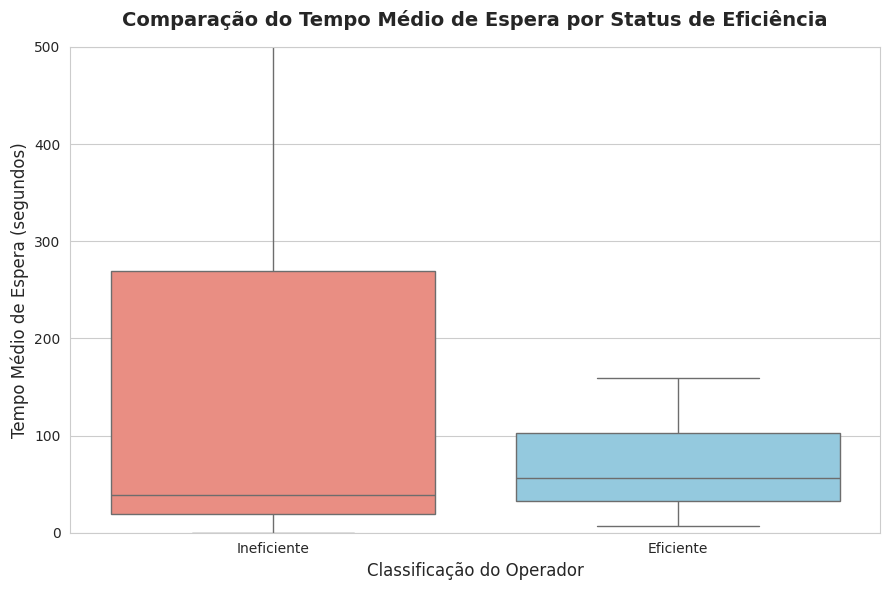

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurando a janela do gráfico
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# 2. Criando o Boxplot para comparar as distribuições
sns.boxplot(
    x='classificacao',
    y='tempo_espera_medio',
    data=operadores_resumo,
    palette=['salmon', 'skyblue'],
    order=['Ineficiente', 'Eficiente']
)

# 3. Customizações de títulos e eixos
plt.title('Comparação do Tempo Médio de Espera por Status de Eficiência', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classificação do Operador', fontsize=12)
plt.ylabel('Tempo Médio de Espera (segundos)', fontsize=12)

# 4. Ajuste crucial: limitando o eixo Y para dar zoom nas caixas e ignorar os outliers gigantes
plt.ylim(0, 500)

# 5. Exibindo o gráfico
plt.tight_layout()
plt.show()

### 3.4. Análise Visual dos Fatores de Ineficiência
Como o teste estatístico comprovou que o tempo de espera é similar entre os grupos, vamos gerar um gráfico comparando as outras duas métricas (Média de Chamadas Perdidas e Média de Chamadas Ativas Realizadas). Isso nos ajudará a visualizar claramente qual pilar está a arrastar a eficiência dos operadores para baixo.

/tmp/ipykernel_7529/2182141808.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7529/2182141808.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


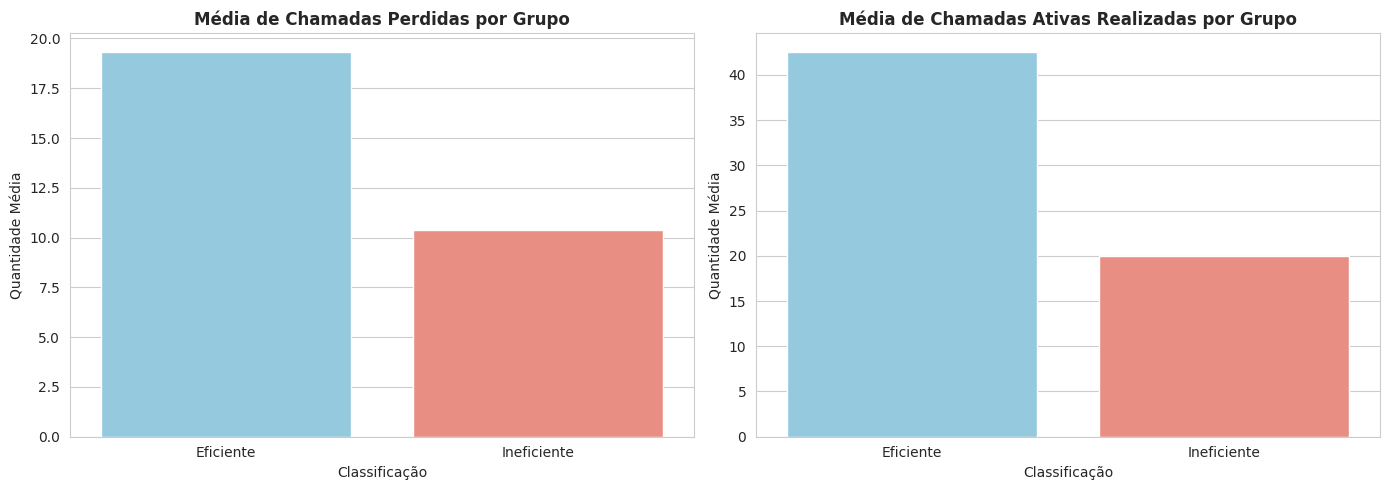

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando as médias das métricas para cada grupo
medias_grupos = operadores_resumo.groupby('classificacao')[['chamadas_perdidas', 'chamadas_ativas_realizadas']].mean().reset_index()

# 2. Configurando a janela com dois gráficos lado a lado (Subplots - super ensinado em aulas!)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_style("whitegrid")

# Gráfico 1: Média de Chamadas Perdidas
sns.barplot(
    x='classificacao',
    y='chamadas_perdidas',
    data=medias_grupos,
    palette=['skyblue', 'salmon'],
    ax=axes[0]
)
axes[0].set_title('Média de Chamadas Perdidas por Grupo', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classificação')
axes[0].set_ylabel('Quantidade Média')

# Gráfico 2: Média de Chamadas Ativas Realizadas
sns.barplot(
    x='classificacao',
    y='chamadas_ativas_realizadas',
    data=medias_grupos,
    palette=['skyblue', 'salmon'],
    ax=axes[1]
)
axes[1].set_title('Média de Chamadas Ativas Realizadas por Grupo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classificação')
axes[1].set_ylabel('Quantidade Média')

plt.tight_layout()
plt.show()

## 4. Conclusões Estratégicas e Plano de Ação

### 4.1. Diagnóstico do Cenário Atual (Sumário Executivo)
Após uma análise aprofundada dos dados operacionais da CallMeMaybe, que incluiu o tratamento de dados nulos/duplicados, a criação de métricas de desempenho e a validação por testes estatísticos, o diagnóstico revela um cenário crítico que requer atenção imediata da gestão:

* **Involução Sistémica da Eficiência:** **71,70% dos operadores (783 profissionais)** foram classificados como ineficientes por apresentarem desempenho abaixo do esperado em pelo menos um dos pilares operacionais da empresa.
* **O Verdadeiro Gargalo (O Insight do Teste Estatístico):** O teste estatístico de Mann-Whitney comprovou que **o tempo médio de espera na linha NÃO é o fator que diferencia os operadores**. O que está a arrastar a eficiência da empresa para baixo é o **abandono de chamadas (altas taxas de chamadas perdidas)** e a **ociosidade/baixa produtividade nas chamadas ativas (outbound)**.
* **Impacto no Negócio:** Clientes que enfrentam chamadas perdidas tendem a cancelar o serviço (*churn*), gerando prejuízo financeiro direto e arranhando a reputação da CallMeMaybe no mercado.

---

### 4.2. Plano de Ação Recomendado (Soluções Práticas)
Com base nos achados, sugerimos as seguintes ações para os líderes de equipa e gestores reverterem este cenário rapidamente:

1. **Engajamento Operacional:** Dado que o tempo de conversa está dentro do padrão normal, o problema está na *disponibilidade* para atender. Recomenda-se criar alertas visuais ou sonoros no sistema da CallMeMaybe quando uma chamada estiver na fila sem nenhum operador vinculado, reduzindo drasticamente a taxa de chamadas perdidas.
2. **Revisão de Metas para Chamadas Ativas (Outbound):** Como identificamos que 25% dos operadores realizam apenas 1 ou nenhuma chamada ativa, é necessário auditar as ferramentas de discagem e recalibrar as metas diárias de ligações realizadas, garantindo que a equipa de saída se mantenha produtiva.
3. **Treinamento e Redistribuição de Demanda:** Em vez de focar em pressionar os operadores a "atender mais rápido" (visto que o tempo de espera não é a raiz do problema), a gestão deve focar em capacitar os funcionários a reter as ligações e redistribuir os profissionais de acordo com os horários de maior pico de chamadas recebidas (*inbound*).